<a href="https://colab.research.google.com/github/ohta-ee-ous/Lecture_ImageProcessing/blob/main/%E7%94%BB%E5%83%8F%E5%87%A6%E7%90%86%E6%BC%94%E7%BF%92_5_2%E5%80%A4%E7%94%BB%E5%83%8F%E5%87%A6%E7%90%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
デジタル画像処理演習

# **2値画像処理**

2026/05/11 改訂

---

この演習では、2値画像処理に関して次の内容を学習します。

1. 画像の2値化
1. ラベリング
1. モルフォロジー演算
1. 図形の形状特徴

次に書かれている「準備」から順番に進めていってください。

<a name="junbi"></a>
# **準備**

最初に準備を行います。次のコードを実行してください。

In [ ]:
#@title ⌨ 準備
# 外部モジュールを取り込む
import cv2
import numpy as np
from google.colab import output
from google.colab.patches import cv2_imshow
from ipywidgets import interact, IntSlider

# ユーザーのディスプレイの解像度に合わせて画像の画面表示サイズを調整する
screen_resolution = output.eval_js('[window.screen.width, window.screen.height, screen.orientation.type]')
screen_scale = max(screen_resolution[:2])/1920
def show_image(img):
  if screen_scale >= 1.0:
    cv2_imshow(img)
  else:
    cv2_imshow(cv2.resize(img, None, fx=screen_scale, fy=screen_scale))

# フォントの種類のリスト
fonts = [cv2.FONT_HERSHEY_SIMPLEX,         # fonts[0]
         cv2.FONT_HERSHEY_PLAIN,           # fonts[1]
         cv2.FONT_HERSHEY_DUPLEX,          # fonts[2]
         cv2.FONT_HERSHEY_COMPLEX,         # fonts[3]
         cv2.FONT_HERSHEY_TRIPLEX,         # fonts[4]
         cv2.FONT_HERSHEY_COMPLEX_SMALL,   # fonts[5]
         cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,  # fonts[6]
         cv2.FONT_HERSHEY_SCRIPT_COMPLEX,] # fonts[7]

# 使用するデータをダウンロードする。
!wget -nc "https://github.com/ohta-ee-ous/Lecture_ImageProcessing/releases/download/v1.0.0/imagefiles.zip" -O imagefiles.zip
!unzip -nq imagefiles.zip
!rm -f imagefiles.zip
!if [[ -f "asagao.png" && -f "README.txt" ]]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi

「準備が完了しました。」と表示されれば成功です。
次のライブラリや関数が使えるようになっています。

|名称|説明|
|:---|:---|
|cv2|画像処理ライブラリ OpenCV|
|np|数値計算ライブラリ NumPy|
|cv2_imshow|Colab専用の画像表示関数|

画像ファイルも用意されています。Colab の画面の左端にある「ファイル」アイコン（📁の形）をクリックするとファイルブラウザが表示されて、ファイルの一覧を見ることができます。もう一度クリックすると非表示になります。  
自分のパソコンに保存してある画像ファイルを Colab で使いたい場合には、このファイルブラウザの中へ画像ファイルをドラッグ＆ドロップしてください。

<br>

# **1．画像の2値化**

まず、原画像を読み込みます。次のコードを実行してください。

In [ ]:
#@title ⌨ 原画像の読み込み
src = cv2.imread('hello.jpg')
show_image(src)

続けて、グレイスケール画像に変換します。次のコードを実行してください。

In [ ]:
#@title ⌨ グレイスケール画像に変換
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
show_image(gray)

## 閾値処理

この画像を2値化してみましょう。

画像の2値化には、`cv2.threshold`関数を使用します。

<h3>使い方</h3>

*val*, *dst* = <tt>cv2.threshold</tt>( *src*, *thresh*, *maxval*, *type* )

- *src* : 入力画像の変数を与える。
- *thresh* : 閾値を与える。
- *maxval* : 2値化後の最大画素値を与える。
- *type* : 2値化手法を指定する。
  - <tt>cv2.THRESH_BINARY</tt> : 0 と *maxval* で2値化する。
  - <tt>cv2.THRESH_OTSU</tt> : 判別分析2値化法（大津の2値化手法）（*thresh*の値は無視される）
- *val* : 2値化の閾値の変数を与える。（判別分析2値化法で閾値を自動決定した場合に使用する）
- *dst* : 出力画像の変数を与える。

次のコードを実行すると、2値化の閾値を調節するスライダーと、2値化された画像が表示されます。スライダーを動かして、2値化画像の変化を見てください。

In [ ]:
#@title ⌨ 閾値を変えて2値化する
@interact(th = IntSlider(min=0, max=255, step=1, value=128, description='閾値'))
def binaryzation(th):
  _, bin = cv2.threshold(gray, th, 255, cv2.THRESH_BINARY)
  show_image(bin)

「Hello!」の文字だけがきれいに抽出できる閾値を探してみましょう。

## 判別分析2値化法

判別分析2値化法は、2値化の最適な閾値を自動で見つける手法です。  
次のコードを実行してください。

In [ ]:
#@title ⌨ 判別分析2値化法
th, bin = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
show_image(bin)
print('閾値 =', th)

2値化された画像と、算出された最適な閾値が表示されます。文字だけがきれいに表示できていますね。

この後の処理のために、画像をネガポジ反転（白黒反転）しておきます。次のコードを実行してください。

In [ ]:
#@title ⌨ ネガポジ反転
img = 255-bin
show_image(img)

この後の処理は、図形は白（値 1）、背景は黒（値 0）という前提で進めていきます。

<br>

# **2．ラベリング**

2値画像の連結成分を見つけ、それぞれに記号（番号）をつける処理のことをラベリングといいます。

ラベリングを行うには、`cv2.connectedComponents`関数を使用します。

<h3>使い方</h3>

*n*, *labels* = <tt>cv2.connectedComponents</tt>( *src* )

- *src* : 入力画像の変数を与える。
- *n* : ラベル数を受け取る変数を与える。
- *labels* : 作成されたラベル画像を受け取る変数を与える。（ラベル番号が画素値になっている）

次のコードは、2値画像のラベリングを行って、連結成分を色分けてして表示します。
コードを実行して、ラベリングの処理結果を見てください。

In [ ]:
#@title ⌨ ラベリング
n, labels = cv2.connectedComponents(img)
# ラベルごとに色を塗り分ける
labels = (labels % 256) * 255 // (n-1)
labels = labels.astype('uint8')
labelimg = cv2.applyColorMap(labels, cv2.COLORMAP_TURBO)
show_image(labelimg)
print('ラベルの数 =', n)

連結成分は、H、e、l、l、o それぞれに一つずつ、! に二つあり、合計で7個です。
さらに`cv2.connectedComponents`関数は、背景も連結成分の一つとして数えますので、付けられたラベルの数は 8 となります。

他の画像でもラベリングを試してみましょう。  
次のコードは、変数`string`に代入した文字列を画像にします。

In [ ]:
#@title ⌨ 画像を作ってラベリングを行う

# 画像にしたい文字列の設定
string = '%Nice!!' # 画像にする文字列（半角英字、半角数字、半角記号のみ）
face = 6           # フォントの種類（準備のコードにある一覧を参照）
scale = 3.5        # フォントのサイズ（実数値）　画像からはみ出る場合は値を小さくする
thickness = 9      # フォントの太さ（整数値）

# 文字列が画像の中央に表示されるように、描画の起点の座標(x,y)を計算する
(x, y), baseline = cv2.getTextSize(string, fonts[face], scale, thickness)
x, y = (src.shape[1]-x)//2, (src.shape[0]+y-baseline)//2
# 画像に文字列を白色で描画する
textimage = np.zeros((360, 480), 'uint8')
cv2.putText(textimage, string, (x, y), fonts[face], scale, 255, thickness)

n, labels = cv2.connectedComponents(textimage)
# ラベルごとに色を塗り分ける
labels = (labels % 256) * 255 // (n-1)
labels = labels.astype('uint8')
labelimg = cv2.applyColorMap(labels, cv2.COLORMAP_TURBO)
print('原画像')
show_image(textimage)
print('\nラベル画像 / ラベルの数 =', n)
show_image(labelimg)

「%Nice!!」という形の図形がラベリングされました。文字がくっついていると一つの連結成分になることに注目してください。  
変数`string`の文字列を変えてみて、ラベリングの結果を確かめましょう。

<br>

# **3．モルフォロジー演算**

モルフォロジー演算とは、画像内の図形の形を修正したり、強調したりする演算処理です。  
代表的なものとして、図形に含まれるノイズを消して、図形を綺麗な形に修正する「膨張」、「収縮」があります。

##ノイズのある画像の作成

2値画像のモルフォロジー演算を試すために、2値画像にノイズを付加します。  
次のコードを実行してください。

In [ ]:
#@title ⌨ ノイズの付加
num = 600             # ノイズの量
noisyimg = img.copy() # noisyimgにsrcのコピーをとる
for _ in range(num):
  x = np.random.randint(0, src.shape[1]) # x,yの値を乱数で決める
  y = np.random.randint(0, src.shape[0])
  noisyimg[y, x] = 0   # 座標(x,y)に黒色ノイズを付加
  x = np.random.randint(0, src.shape[1]) # x,yの値を乱数で決める
  y = np.random.randint(0, src.shape[0])
  noisyimg[y, x] = 255 # 座標(x,y)に黒色ノイズを付加
show_image(noisyimg)

画像の全体に白色のノイズが散らばっています。また、文字の上には黒色のノイズが載って、小さな穴が開いています。

次のコードも実行してください。ここで作られる`kernel4`と`kernel8`は、ぞれぞれ4連結と8連結の構造の形状を表すものです。

In [ ]:
#@title ⌨ カーネルの設定
# 4連結用のカーネル
kernel4 = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
print('kernel4 = ')
print(kernel4)
# 8連結用のカーネル
kernel8 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
print('\nkernel8 = ')
print(kernel8)

## 膨張

膨張は、図形をひとまわり大きくする（太らせる）処理です。これによって、図形の中にある小さな穴を塞ぐことができます。幾何学的変換の「拡大」とは異なることに注意してください。

2値画像に膨張処理を行うには、`cv2.dilate`関数を使用します。

<h3>使い方</h3>

*dst* = <tt>cv2.dilate</tt>( *src*, *kernel* )

- *src* : 入力画像の変数を与える。
- *kernel* : 構造要素を与える。（4連結で処理する場合は`kernel4`、8連結で処理する場合は`kernel8`を与える）
- *dst* : 出力画像の変数を与える。

先ほど作成したノイズの画像に膨張処理を行ってみましょう。  
次のコードを実行してください。

In [ ]:
#@title ⌨ 膨張処理
dst = cv2.dilate(noisyimg, kernel8)
show_image(dst)

図形が膨張したことで、図形の中にあった黒い点が消えましたね。しかし、逆に、図形の周囲にある白い点のノイズは大きくなってしまいます。

### ✍ 実践問題 1

膨張処理を次のように変えてみよう。

1. 膨張を3回繰り返すようにしよう。  
ヒント: 膨張結果の画像`dst`に対して膨張処理を繰り返し行う。
1. さらにカーネルを4連結の`kernel4`に変えて、8連結の`kernel8`の場合との違いを見てみよう。

<details><summary>答え</summary>

1.
```
dst = cv2.dilate(noisyimg, kernel8)
dst = cv2.dilate(dst, kernel8)
dst = cv2.dilate(dst, kernel8)
```
2.
```
dst = cv2.dilate(noisyimg, kernel4)
dst = cv2.dilate(dst, kernel4)
dst = cv2.dilate(dst, kernel4)
```

</details>

In [ ]:
#@title ⌨ 実践問題用コード 1
dst = cv2.dilate(noisyimg, kernel8)
show_image(dst)

## 収縮

収縮は、図形をひとまわり小さくする（細らせる）処理です。これによって、図形の周囲にある小さな点を消すことができます。幾何学的変換の「縮小」とは異なることに注意してください。

2値画像に収縮処理を行うには、`cv2.erode`関数を使用します。

<h3>使い方</h3>

*dst* = <tt>cv2.erode</tt>( *src*, *kernel* )

- *src* : 入力画像の変数を与える。
- *kernel* : 構造要素を与える。（4連結で処理する場合は`kernel4`、8連結で処理する場合は`kernel8`を与える）
- *dst* : 出力画像の変数を与える。

ノイズの画像に収縮処理を行ってみましょう。
次のコードを実行してください。

In [ ]:
#@title ⌨ 収縮処理
dst = cv2.erode(noisyimg, kernel8)
show_image(dst)

図形が収縮することで、図形の周囲の白い点のノイズが消えましたね。しかし、図形の中にある黒い点のノイズは大きくなってしまいます。

### ✍ 実践問題 2

収縮処理を次のように変えてみよう。

1. 収縮を3回繰り返すようにしよう。  
1. さらにカーネルを4連結の`kernel4`に変えて、`kernel8`との違いを見てみよう。

<details><summary>答え</summary>

1.
```
dst = cv2.erode(noisyimg, kernel8)
dst = cv2.erode(dst, kernel8)
dst = cv2.erode(dst, kernel8)
```
2.
```
dst = cv2.erode(noisyimg, kernel4)
dst = cv2.erode(dst, kernel4)
dst = cv2.erode(dst, kernel4)
```

</details>

In [ ]:
#@title ⌨ 実践問題用コード 2
dst = cv2.erode(noisyimg, kernel8)
show_image(dst)

## クロージング

クロージングは、膨張→収縮の順序で処理を行うものです。

次のコードは、膨張処理の出力画像を変数`tmp`に 記憶した後、`tmp`に対して収縮処理を行います。  
このコードを実行して、クロージングの結果を確かめてください。

In [ ]:
#@title ⌨ クロージング処理
tmp = cv2.dilate(noisyimg, kernel8) # 膨張
dst = cv2.erode(tmp, kernel8)       # 収縮
show_image(dst)

図形の穴は塞がります。周囲のノイズの点は元の大きさのまま残ります。

## オープニング

オープニングは、収縮→膨張の順序で処理を行うものです。

次のコードは、収縮処理の出力画像を変数`tmp`に 記憶した後、`tmp`に対して膨張処理を行います。
このコードを実行して、オープニングの結果を確かめてください。

In [ ]:
#@title ⌨ オープニング処理
tmp = cv2.erode(noisyimg, kernel8) # 収縮
dst = cv2.dilate(tmp, kernel8)     # 膨張
show_image(dst)

周囲のノイズの点は消えます。図形の穴は元の大きさのまま残ります。

## クロージングとオープニングの連続処理

クロージングでは図形の穴は塞がりますが、周囲のノイズは残ります。一方、オープニングは周囲のノイズは消えますが、図形の穴は残ります。

では、クロージングとオープニングの処理を連続して行ったらどうなるでしょうか。次のコードを実行してください。

In [ ]:
#@title ⌨ クロージング→オープニング
# クロージング
tmp = cv2.dilate(noisyimg, kernel8) # 膨張
tmp = cv2.erode(tmp, kernel8)       # 収縮
# オープニング
tmp = cv2.erode(tmp, kernel8)       # 収縮
dst = cv2.dilate(tmp, kernel8)      # 膨張
show_image(dst)

図形の穴と周囲の点のどちらも消すことができました。  
このように、クロージングとオープニングの処理は、2値画像のノイズ除去として有効な方法です。

### ✍ 実践問題 3

オープニングの後にクロージングを行うように変えてみよう。

<details><summary>答え</summary>

```
# オープニング
tmp = cv2.erode(noisyimg, kernel8) # 収縮
tmp = cv2.dilate(tmp, kernel8)     # 膨張
# クロージング
tmp = cv2.dilate(tmp, kernel8)     # 膨張
dst = cv2.erode(tmp, kernel8)      # 収縮
```

</details>

In [ ]:
#@title ⌨ 実践問題用コード 3
tmp = cv2.dilate(noisyimg, kernel8)
tmp = cv2.erode(tmp, kernel8)
tmp = cv2.erode(tmp, kernel8)
dst = cv2.dilate(tmp, kernel8)
show_image(dst)

## 細線化

細線化は、収縮を応用した処理です。画像に収縮を繰り返し行い続けると最終的に図形がすべて消えてしまいます。一方、細線化は、画像の端点や連結性を残しながら、最終的に1画素幅の図形になるまで収縮を行います。これによって、図形の骨格を得ることができます。

次のコードを実行して、細線化を見てみましょう。

In [ ]:
#@title ⌨ 細線化
dst = cv2.ximgproc.thinning(img, cv2.ximgproc.THINNING_ZHANGSUEN)
show_image(dst)

太さが1画素の線で文字の骨格が得られました。このように、図形の太さがなくなりますので、図形の端点や交点、分岐点などの位置が抽出しやすくなります。

<br>

# **4．図形の形状特徴**

図形の形状特徴には、面積、周囲長、重心座標、円形度、外接長方形の大きさ、外接円の大きさなどがあります。

まず、原画像を読み込んで2値画像を作ります。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('shape.png')
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
_, img = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV)
show_image(img)

図形は白（値 1）、背景は黒（値 0）になっています。

## モーメント特徴

画像 $f$ を次のような2値画像とします。
$$f(x,y)=\left\{
\begin{array}{ll}
0&\mbox{背景の領域}\\1&\mbox{図形の領域}
\end{array}
\right.$$

このとき、モーメント特徴は、
$$m(p,q)=\sum_{x,y}x^py^qf(x,y)$$
によって計算できます。

モーメント特徴の計算には、`cv2.moments`関数を使用します。

<h3>使い方</h3>

*values* = <tt>cv2.moments</tt>( *src* )

- *src* : 入力画像の変数を与える。
- *values* : 計算されたモーメント特徴を受け取る変数を与える。

モーメント特徴 $m(p,q)$ は、$p$と$q$の違いによって複数の値が存在します。
コードでは次のように記述します。（変数名を`values`とします。）

$m(0,0)$ → `values['m00']`  
$m(1,0)$ → `values['m10']`  
$m(0,1)$ → `values['m01']`  
$m(1,1)$ → `values['m11']`

次のコードを実行して、画像のモーメント特徴の値を求めてみましょう。

In [ ]:
#@title ⌨ モーメント特徴を求める
bin = img // 255 # 画素値の範囲{0,255}を{0,1}に変換する
values = cv2.moments(bin)
print('m(0,0) =', values['m00'])
print('m(1,0) =', values['m10'])
print('m(0,1) =', values['m01'])
print('m(1,1) =', values['m11'])

モーメント特徴を利用すると、図形の重心の座標 $(x_c, y_c)$ を次式で求めることができます。
$$x_c = \frac{m(1,0)}{m(0,0)},~~y_c = \frac{m(0,1)}{m(0,0)}$$

また、重心周りのモーメント特徴は次式で定義されます。
$$\mu(p,q)=\sum_{x,y} (x-x_c)^p(y-y_c)^qf(x,y)$$

これを用いて、図形の主軸の角度 $\theta$ を次式で求めることができます。
$$\theta = \frac{1}{2}\tan^{-1}\frac{2\mu(1,1)}{\mu(2,0)-\mu(0,2)}$$

重心周りのモーメント特徴は次のようにコードで記述します。

$\mu(0,0)$ → `values['mu00']`  
$\mu(1,1)$ → `values['mu11']`  
$\mu(2,0)$ → `values['mu20']`  
$\mu(0,2)$ → `values['mu02']`

## 重心と主軸の角度

これらを利用して、画像に、図形の重心の位置に点を描き、主軸を直線で描くコードが次のように作ることができます。

このコードを実行して、重心と主軸の位置を調べてみましょう。

In [ ]:
#@title ⌨ 重心と主軸を求める
bin = img // 255
values = cv2.moments(bin)
# 重心の座標(xc,yc)を求める
xc = values['m10'] / values['m00']
yc = values['m01'] / values['m00']
print(f'重心の座標 = ({xc:.1f}, {yc:.1f})')
# 主軸の角度を求める
rad = np.arctan2(2*values['mu11'], values['mu20']-values['mu02'] )/2
deg = np.degrees(rad)
print(f'主軸の角度 = {deg:.1f} 度')
# 重心と主軸を描画
c = np.intp((xc, yc))
x, y = int(np.cos(rad)*1000), int(np.sin(rad)*1000)
dst = cv2.merge([img//2, img//2, img//2]) # imgをもとにカラー画像を作り、dstに記憶する
cv2.line(dst, c-(x,y), c+(x,y), (100, 255, 100), 2, cv2.LINE_AA)  # 緑色で主軸を描く
cv2.circle(dst, c, 7, (0, 0, 255), -1, cv2.LINE_AA)  # 赤色で重心の点を描く
show_image(dst)

重心の位置は赤色の点で表され、主軸は緑色の直線で描かれています。

## 輪郭追跡

図形の外周の画素を順に辿って図形の輪郭を検出する処理のことを輪郭追跡と言います。  
図形の輪郭追跡の結果から、図形の面積、周囲長、円形度を求めることができます。  
面積はモーメント特徴で計算できますが、ここで使用する面積は、図形の中にある穴もすべて埋めた場合の面積です。

輪郭追跡を行うには、`cv2.findContours`関数を使用します。
<h3>使い方</h3>

*contours*, *hierarchy* = <tt>cv2.findContours</tt>( *src*, *mode*, *method* )

- *src* : 入力画像の変数を与える。
- *mode* : 輪郭追跡アルゴリズムのモードを設定する。  
  - <tt>cv2.RETR_EXTERNAL</tt> : 最も外側の輪郭線を検出する。  
  - <tt>cv2.RETR_LIST</tt> : 図形の穴も含めたすべての輪郭線を検出する。
- *method* : 輪郭線の近似方法を設定する。  
  - <tt>cv2.CHAIN_APPROX_NONE</tt> : すべての点を取る。  
  - <tt>cv2.CHAIN_APPROX_SIMPLE</tt> : 角などの頂点だけで近似する。
  - <tt>cv2.CHAIN_APPROX_TC89_L1</tt> : Tech-Chinチェーンアルゴリズムで近似する。（精度が高い）
- *contours* : 検出された輪郭線のリストを受け取る変数を与える。
- *hierarchy* : 輪郭線の階層構造の情報を受け取る変数を与える。（今回は使用しない）

次のコードを実行して、輪郭追跡の結果を確認しましょう。

In [ ]:
#@title ⌨ 輪郭追跡
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_L1)
# 輪郭線を描画する
dst = cv2.merge([img//2, img//2, img//2])
cv2.drawContours(dst, contours, 0, (100, 255, 100), 2) # 輪郭線を描く
show_image(dst)

輪郭線が緑色の線で描かれています。

## 図形の面積と周囲長

図形の輪郭線から図形の面積、周囲長を求めてみましょう。

図形の面積の計算には、`cv2.contourArea`関数を使用します。また、
周囲長の計算には、`cv2.arcLength`関数を使用します。

<h3>使い方</h3>

*area* = <tt>cv2.contourArea</tt>( *contour* )

- *contour* : 図形の輪郭線の情報を与える。
- *area* : 面積の値を受け取る変数を与える。  

*length* = <tt>cv2.arcLength</tt>( *contour*, *closed* )

- *contour* : 図形の輪郭線の情報を与える。
- *closed* : 輪郭線が閉じているか、いないかを論理値で指定する。
  - <tt>True</tt> : 閉じている
  - <tt>False</tt> : 閉じていない
- *length* : 輪郭線の長さを受け取る変数を与える。  

次のコードを実行して、図形の面積と周囲長を調べてください。

In [ ]:
#@title ⌨ 面積と周囲長を求める
contour = contours[0] # 0番目の輪郭線情報を取り出す
S = cv2.contourArea(contour)
L = cv2.arcLength(contour, True)
print(f'面積 = {S:.1f}')
print(f'周囲長 = {L:.1f}')

## 図形の円形度

図形の面積$S$と周囲長$L$から、図形の円形度$F$が次の式で計算できます。
$$F=\frac{4\pi S}{L^2}$$

次のコードを実行して円形度を調べましょう。`np.pi`は円周率$\pi$の値をもつ定数です。

In [ ]:
#@title ⌨ 円形度を求める
F = 4*np.pi*S / L**2
print(f'円形度 = {F:.3f}')

円形度は $0\leqq F \leqq 1$の値をとります。真円（正円）の形状のとき $1$ になり、形状が複雑になるほど値が小さくなります。

### ✍ 実践問題 4

次のコードは正$n$角形の画像を作成して円形度の計算を行います。まずは$n$の値を変えて、いろいろな多角形の円形度を求めてみましょう。

ディジタル的に描かれた図形から求めた円形度には誤差が生じます。どのくらいの誤差があるのか確かめましょう。

1. 正方形の円形度の理論値はいくつですか？ 自分で計算してみましょう。  
画像から計算された値の誤差を調べましょう。
1. 正三角形の円形度の理論値はいくつですか？  
画像から計算された値の誤差を調べましょう。
1. 正六角形の円形度の理論値はいくつですか？  
画像から計算された値の誤差を調べましょう。

<details><summary>答え</summary>

1. 正方形の円形度の理論値は、$F=\frac{\pi}{4}\simeq 0.785$
1. 正三角形の円形度の理論値は、$F=\frac{\pi\sqrt{3}}{9}\simeq 0.605$
1. 正六角形の円形度の理論値は、$F=\frac{\pi\sqrt{3}}{6}\simeq 0.907$

1辺の長さが$1$の正$n$角形の周囲長と面積は、次のコードで計算できます。
```
# 周囲長
perimeter = n
# 面積
area = n/(4*np.tan(np.pi/n))
```

</details>

In [ ]:
#@title ⌨ 実践問題用コード 4
#@markdown 正n角形を描く
n = 4 # @param {type:"integer"} n角形の頂点数
if n < 3:
  print('入力エラー： n≧3 の整数を入力してください。')
else:
  w, h = 480, 360
  image = np.zeros((h, w), np.uint8)
  cx, cy = w // 2, h // 2
  r = int(h * 0.4)
  st = 2*np.pi/n
  points = []
  for i in range(n):
      ang = i*st
      x, y = cx+int(r*np.sin(ang)), cy-int(r*np.cos(ang))
      points.append((x, y))
  points = np.array(points, np.int32)
  cv2.fillConvexPoly(image, points, 255)
  show_image(image)
  contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_L1)
  contour = contours[0]
  S = cv2.contourArea(contour)
  L = cv2.arcLength(contour, True)
  F = 4*np.pi*S / L**2
  print(f'円形度 = {F:.3f}')


## 外接長方形

図形の輪郭線から、`cv2.boundingRect`関数を使って図形の外接長方形を求めることができます。  

<h3>使い方</h3>

*x*, *y*, *h*, *w* = <tt>cv2.boundingRect</tt>( *array* )

- *array* : 頂点座標群を与える。
- *x*, *y* : 長方形の左上座標を受け取る変数を与える。
- *w*, *h* : 長方形の横幅、縦幅を受け取る変数を与える。

次のコードを実行してください。

In [ ]:
#@title ⌨ 外接長方形を求める
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_L1)
contour = contours[0]
dst = cv2.merge([img//2, img//2, img//2])
x,y,w,h = cv2.boundingRect(contour)
cv2.rectangle(dst, (x, y), (x+w-1, y+h-1), (80, 240, 80), 2, cv2.LINE_AA) # 長方形を描く
show_image(dst)
print(f'長方形の左上頂点 = ({x}, {y})')
print(f'幅 = {w}、高さ = {h}')

`cv2.boundingRect`関数で得られる長方形は、横と縦の辺がそれぞれ$x$軸と$y$軸に平行になります。

面積が最小になるような外接長方形を得る場合には、`cv2.minAreaRect`関数を使用します。

<h3>使い方</h3>

*rect* = <tt>cv2.minAreaRect</tt>( *array* )

- *array* : 頂点座標群を与える。
- *rect* : 長方形の形状を受け取る変数を与える。

次のコードを実行して、上の結果と見比べてください。

In [ ]:
#@title ⌨ 面積最小の外接長方形を求める
dst = cv2.merge([img//2, img//2, img//2])
rect = cv2.minAreaRect(contour)
box = cv2.boxPoints(rect) # 長方形の4頂点の座標を得る
cv2.drawContours(dst, [np.intp(box)], 0, (80, 240, 80), 2, cv2.LINE_AA) # 四角形を描く
show_image(dst)
print(f'長方形の中心 = ({rect[0][0]:.1f}, {rect[0][1]:.1f})')
print(f'幅 = {rect[1][0]:.1f}、高さ = {rect[1][1]:.1f}、回転角度 = {rect[2]:.1f} 度')

## 外接円

図形の輪郭線から、`cv2.minEnclosingCircle`関数を使用して図形の外接が得られます。

<h3>使い方</h3>

*c*, *r* = <tt>cv2.minEnclosingCircle</tt>( *array* )

- *array* : 頂点座標群を与える。
- *c*, *r* : 円の中心座標と半径を受け取る変数を与える。

次のコードを実行してください。

In [ ]:
#@title ⌨ 外接円を求める
dst = cv2.merge([img//2, img//2, img//2])
c, r = cv2.minEnclosingCircle(contour)
cv2.circle(dst, np.intp(c), int(r), (80, 240, 80), 2, cv2.LINE_AA) # 円を描く
show_image(dst)
print(f'円の中心 = ({c[0]:.1f}, {c[1]:.1f})\n半径 = {r:.1f}')

以上で演習は終了です。

<br>

---
Copyright © 2026 OHTA Hiroshi @ Okayama University of Science  
<small>岡山理科大学 工学部 電気電子システム学科 太田研究室</small>

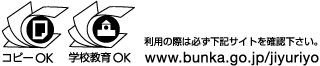  
この演習は、大学講義科目「画像工学」の講義資料として作成されています。  
このipynbファイルは、学校教育のための非営利目的利用を認めます。[https://www.bunka.go.jp/jiyuriyo](https://www.bunka.go.jp/jiyuriyo)  
この演習で使用している画像ファイル（imagefiles.zip、及び、imagefiles.zip 内の個々のファイル）については再配布を禁止します。